# Time Series Analysis — ARIMAModel
## RELIANCE.NS | 2005 | With Stationarity Phase

**Pipeline:**
1. Data Collection (yfinance)
2. **Stationarity Testing (ADF Test)**
3. **Differencing + ACF/PACF Analysis**
4. Normalization (MinMaxScaler on stationary data)
5. Train/Test Split
6. AR Model Grid Search
7. Best Model Evaluation
8. Inverse Transform → Original Price Scale
9. Forecasting

---
## Step 1: Install & Import Libraries

In [1]:
!pip install yfinance statsmodels scikit-learn matplotlib --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2: Download Stock Data

In [3]:
ticker = "RELIANCE.NS"
year = 2005
start_date = f"{year}-01-01"
end_date   = f"{year}-12-31"

stk_data = yf.download(ticker, start=start_date, end=end_date, progress=False)

if stk_data.empty:
    print(f"No data available for {ticker} in {year}.")
else:
    stk_data = stk_data[["Open", "High", "Low", "Close"]]
    print(f"OHLC data for {ticker} in {year}:")
    print(stk_data.head())
    print(f"\nShape: {stk_data.shape}")

OHLC data for RELIANCE.NS in 2005:
Price             Open        High         Low       Close
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                      
2005-01-03   32.366290   32.702315   32.030265   32.633308
2005-01-04   33.002341   33.002341   31.778255   31.877262
2005-01-05   31.562243   32.009274   30.971201   31.799257
2005-01-06   31.682238   32.192275   31.337211   31.574232
2005-01-07   32.102274   32.864328   31.655243   32.537304

Shape: (250, 4)


In [4]:
column = "Close"
close_prices = stk_data[[column]].copy()
close_prices.head()

Price,Close
Ticker,RELIANCE.NS
Date,
2005-01-03,32.633308
2005-01-04,31.877262
2005-01-05,31.799257
2005-01-06,31.574232
2005-01-07,32.537304


In [5]:
from sklearn.preprocessing import MinMaxScaler
Ms=MinMaxScaler()
data1=Ms.fit_transform(stk_data[["Close"]])
print("Len:",data1.shape)

Len: (250, 1)


---
## Step 5: Train / Test Split (80/20)

In [6]:
training_size = round(len(data1) * 0.80)
print(f"Training size : {training_size}")
print(f"Test size     : {len(data1) - training_size}")

X_train = data1[:training_size]
X_test  = data1[training_size:]
y_train = data1[:training_size]
y_test  = data1[training_size:]

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

last_train_price = float(close_prices[column].iloc[training_size])
print(f"\nLast original close price at train boundary: {last_train_price:.2f} INR")

Training size : 200
Test size     : 50

X_train shape: (200, 1)
X_test shape : (50, 1)

Last original close price at train boundary: 45.94 INR


In [7]:
"""from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data1, order=(1,1,1))#Autoregressive Integrated Moving Average (ARIMA)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(stk_data), len(stk_data)-1)
print(y_pred)
from stockFunctions import rmsemape
rmsemape(stkk,predicted_stock_price_test_oriP["Open"])"""

'from statsmodels.tsa.arima.model import ARIMA\nmodel = ARIMA(data1, order=(1,1,1))#Autoregressive Integrated Moving Average (ARIMA)\nmodel_fit = model.fit()\n# make prediction\ny_pred= model_fit.predict(len(stk_data), len(stk_data)-1)\nprint(y_pred)\nfrom stockFunctions import rmsemape\nrmsemape(stkk,predicted_stock_price_test_oriP["Open"])'

In [8]:
from sklearn.metrics import mean_squared_error
from stockFunctions import rmsemape
from statsmodels.tsa.arima.model import ARIMA

# Trend options
trends = ['n','t','c','ct']

# ARIMA orders (p,d,q)
orders = [(1,1,1), (2,1,1), (2,1,2)]   # You can change

for order in orders:
    
    for td in trends:
        
        try:
            # Build ARIMA model
            model = ARIMA(X_train, order=order, trend=td)
            model_fit = model.fit()
            
            # Forecast test set properly
            y_pred = model_fit.forecast(steps=len(y_test))
            
            print(f"Order = {order} | Trend = {td}")
            rmsemape(y_test, y_pred)
            print("***********")
            
        except:
            continue

Order = (1, 1, 1) | Trend = n
RMSE-Testset: 0.024392666087498897
MAPE-Testset: 0.15431171767177984
***********
Order = (1, 1, 1) | Trend = t
RMSE-Testset: 0.009137891174454557
MAPE-Testset: 0.05929841028106873
***********
Order = (2, 1, 1) | Trend = n
RMSE-Testset: 0.02436575821182487
MAPE-Testset: 0.15416268760298227
***********
Order = (2, 1, 1) | Trend = t
RMSE-Testset: 0.00914967989926842
MAPE-Testset: 0.059288743879556
***********
Order = (2, 1, 2) | Trend = n
RMSE-Testset: 0.024376187627967137
MAPE-Testset: 0.15421863615790815
***********
Order = (2, 1, 2) | Trend = t
RMSE-Testset: 0.009135443799763285
MAPE-Testset: 0.059297199855529864
***********


In [9]:
best_model = ARIMA(X_train, order=(2,1,2), trend='t')
best_model_fit = best_model.fit()

print(best_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 253.687
Date:                Thu, 05 Mar 2026   AIC                           -495.373
Time:                        12:52:48   BIC                           -475.613
Sample:                             0   HQIC                          -487.376
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0006      0.002      0.310      0.757      -0.003       0.004
ar.L1         -0.8064     30.842     -0.026      0.979     -61.255      59.643
ar.L2          0.0089      0.500      0.018      0.9

In [10]:
# 1️⃣ Forecast
y_pred_scaled = model_fit.forecast(steps=len(X_test))

# 2️⃣ Inverse both
y_pred_original = Ms.inverse_transform(
    y_pred_scaled.reshape(-1,1)
).flatten()

X_test_original = Ms.inverse_transform(
    X_test.reshape(-1,1)
).flatten()

# 3️⃣ Evaluate
rmsemape(X_test_original, y_pred_original)

RMSE-Testset: 1.4421176614867401
MAPE-Testset: 0.022438640091469914


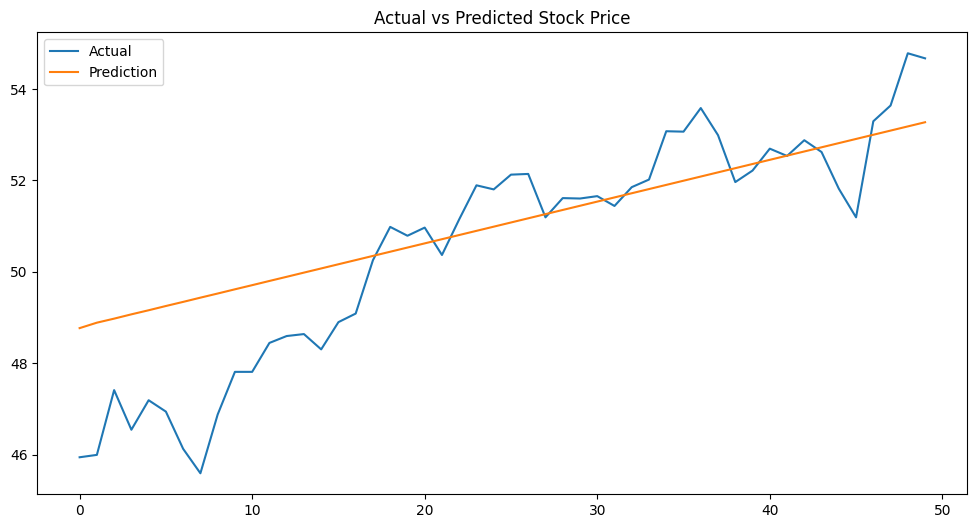

In [11]:
plt.figure(figsize=(12,6))
plt.plot(X_test_original, label="Actual")
plt.plot(y_pred_original, label="Prediction")
plt.legend()
plt.title("Actual vs Predicted Stock Price")
plt.show()

In [12]:
future_scaled = model_fit.forecast(steps=3)

future_original = Ms.inverse_transform(
    future_scaled.reshape(-1,1)
).flatten()

print(future_original)

[48.76861753 48.88787358 48.97626533]
